# EDA inicial — Camada Gold (Fase 2) e microdados de aluno

**Objetivo deste notebook:** explorar os dados disponíveis para decidir a
granularidade do modelo (aluno vs. município) e formular hipóteses analíticas
que embasam as decisões de modelagem no próximo notebook.

> ## Decisão final (premissa para os próximos notebooks)
>
> Com base na EDA abaixo (seção 3 traz o detalhamento completo):
>
> - **Granularidade: aluno, híbrida** — unidade de análise é o aluno
>   individual (`alunos_limpo`/fonte pública), enriquecido com as variáveis
>   territoriais/meta da camada Gold (`indicador_por_municipio`) via
>   `id_municipio`.
> - **Escopo: somente alunos com `presenca == '1'`** — exclui ausentes da
>   avaliação. Remove a regra determinística "ausente ⇒ não alfabetizado"
>   (Hipótese H5) e mantém o problema focado em fatores educacionais reais,
>   não em logística de aplicação da prova.
>
> **A partir daqui, todo notebook de preprocessing/modelagem parte dessas
> duas premissas** — não são reabertas a cada etapa.

Duas fontes são exploradas:

1. **Camada Gold da Fase 3** (`fiapfase2.gold_alfabetizacao`, BigQuery) — dados
   agregados por município/UF/Brasil, já com meta e gap calculados.
2. **Microdados de aluno** (`basedosdados.br_inep_avaliacao_alfabetizacao.alunos`,
   BigQuery público) — nível de aluno individual, com o target `alfabetizado`
   já pronto, mas que **não foi promovido à camada Gold na Fase 2** (ficou só até
   a camada Silver). Consultamos a fonte pública original porque é a mesma fonte
   que alimentou o Silver da Fase 2, e continua acessível com a mesma conta GCP.

> Pré-requisito: `gcloud auth application-default login` já configurado (mesma
> conta usada na Fase 2), projeto `fiapfase2` com acesso de leitura ao BigQuery.

**Escopo desta rodada:** só os dados já disponíveis (Gold + microdados de
aluno). Fontes externas (IBGE, Censo Escolar, FUNDEB, Atlas do Desenvolvimento
Humano, PNAD, Cadastro Único) ficam para uma iteração posterior — decisão
tomada conscientemente para validar o pipeline de ponta a ponta com o que já
temos antes de somar complexidade de integração de novas fontes.


## Como as hipóteses deste notebook são formuladas

Cada hipótese abaixo segue o mesmo formato — **Motivo → Resultado →
Decisão** — porque uma hipótese de EDA só é útil se atender dois critérios ao
mesmo tempo:

1. **É testável com o dado que já temos em mãos**, sem depender de nada
   externo ainda não obtido.
2. **O resultado muda algo concreto** no pipeline de modelagem ou no
   README — se a resposta não muda nenhuma decisão, é estatística
   decorativa, não uma hipótese analítica de verdade.

É a forma de atender ao requisito do desafio de que a EDA "apoie diretamente
as decisões de modelagem" — cada hipótese termina explicitamente na decisão
que ela força, não só na constatação.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

PROJECT_ID = "fiapfase2"
client = bigquery.Client(project=PROJECT_ID)

def bq(sql: str) -> pd.DataFrame:
    return client.query(sql).to_dataframe()


## 1. Camada Gold — visão por município/UF/Brasil

In [2]:
indicador_municipio = bq("SELECT * FROM `fiapfase2.gold_alfabetizacao.indicador_por_municipio`")
comparacao = bq("SELECT * FROM `fiapfase2.gold_alfabetizacao.comparacao_meta_resultado`")
evolucao = bq("SELECT * FROM `fiapfase2.gold_alfabetizacao.evolucao_temporal`")

print("indicador_por_municipio:", indicador_municipio.shape)
print("comparacao_meta_resultado:", comparacao.shape)
print("evolucao_temporal:", evolucao.shape)
indicador_municipio.head()


indicador_por_municipio: (23995, 30)
comparacao_meta_resultado: (24143, 8)
evolucao_temporal: (10548, 4)


,ano,id_municipio,serie,rede,taxa_alfabetizacao,media_portugues,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,proporcao_aluno_nivel_4,proporcao_aluno_nivel_5,proporcao_aluno_nivel_6,proporcao_aluno_nivel_7,proporcao_aluno_nivel_8,taxa_alfabetizacao_meta,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,percentual_participacao,nome,sigla_uf,nome_uf,gap_meta_resultado,atingiu_meta
0,2024,2413102,2,Estadual,23.53,713.5400,5.88,17.65,11.76,23.53,23.53,0.0,17.65,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,Senador Elói de Souza,RN,Rio Grande do Norte,NaN,False
1,2024,4301503,2,Estadual,10.00,702.3348,10.00,10.00,30.00,10.00,40.00,0.0,0.00,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,Augusto Pestana,RS,Rio Grande do Sul,NaN,False
2,2024,2406155,2,Pública (Estadual e Municipal),33.33,728.6200,0.00,6.67,13.33,33.33,33.33,0.0,6.67,0.0,6.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,Jundiá,RN,Rio Grande do Norte,NaN,False
3,2024,2904704,2,Estadual,21.43,719.9300,0.00,7.14,14.29,21.43,57.14,0.0,0.00,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,Buerarema,BA,Bahia,NaN,False
4,2024,4315321,2,Pública (Estadual e Municipal),25.00,723.2140,0.00,25.00,0.00,12.50,50.00,0.0,12.50,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,Quevedos,RS,Rio Grande do Sul,NaN,False


In [3]:
indicador_municipio.info()


<class 'pandas.DataFrame'>
RangeIndex: 23995 entries, 0 to 23994
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ano                      23995 non-null  Int64  
 1   id_municipio             23995 non-null  str    
 2   serie                    23995 non-null  str    
 3   rede                     23995 non-null  str    
 4   taxa_alfabetizacao       23995 non-null  float64
 5   media_portugues          23995 non-null  float64
 6   proporcao_aluno_nivel_0  12448 non-null  float64
 7   proporcao_aluno_nivel_1  12448 non-null  float64
 8   proporcao_aluno_nivel_2  12448 non-null  float64
 9   proporcao_aluno_nivel_3  12448 non-null  float64
 10  proporcao_aluno_nivel_4  12448 non-null  float64
 11  proporcao_aluno_nivel_5  12448 non-null  float64
 12  proporcao_aluno_nivel_6  12448 non-null  float64
 13  proporcao_aluno_nivel_7  12448 non-null  float64
 14  proporcao_aluno_nivel_8  12448 no

In [4]:
# Valores ausentes por coluna
indicador_municipio.isna().mean().sort_values(ascending=False).to_frame("pct_nulo")


,pct_nulo
gap_meta_resultado,0.563909
meta_alfabetizacao_2024,0.563909
taxa_alfabetizacao_meta,0.558908
nivel_alfabetizacao,0.558908
percentual_participacao,0.558908
meta_alfabetizacao_2029,0.555991
meta_alfabetizacao_2028,0.555991
meta_alfabetizacao_2027,0.555991
meta_alfabetizacao_2026,0.555991
meta_alfabetizacao_2025,0.555991


**Observação esperada:** `meta_alfabetizacao_2024` (e as metas de anos seguintes)
devem ter uma taxa de nulos maior que `taxa_alfabetizacao` — nem todo
município tem meta municipal definida na fonte (algumas metas só existem em
nível de UF/Brasil). Isso é uma decisão de imputação real pro pipeline de
modelagem, não um bug de dado.


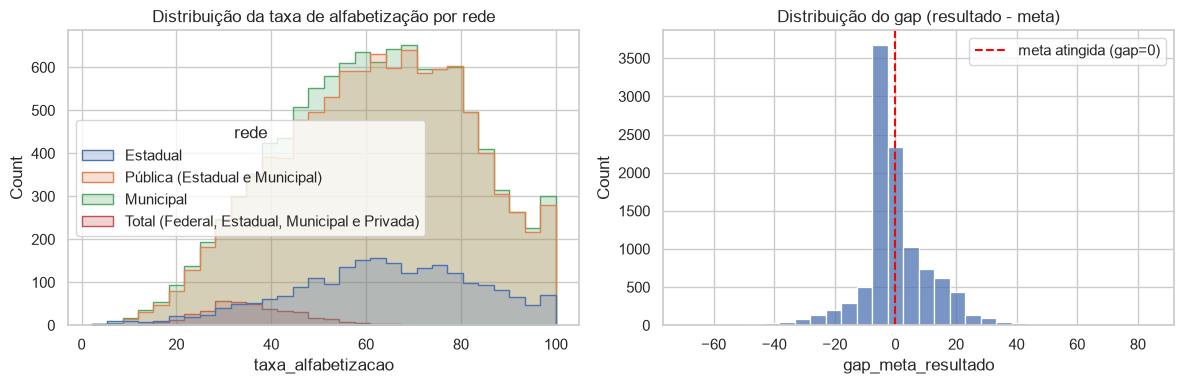

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=indicador_municipio, x="taxa_alfabetizacao", hue="rede", bins=30, ax=axes[0], element="step")
axes[0].set_title("Distribuição da taxa de alfabetização por rede")
sns.histplot(data=indicador_municipio, x="gap_meta_resultado", bins=30, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--", label="meta atingida (gap=0)")
axes[1].set_title("Distribuição do gap (resultado - meta)")
axes[1].legend()
plt.tight_layout()
plt.show()


### Hipótese H1 — Balanceamento do target em nível de município (`atingiu_meta`)

**Motivo para testar agora:** se a granularidade de município for escolhida,
`atingiu_meta` é o candidato natural a target binário — mas a métrica de
avaliação e a estratégia de split dependem diretamente de quão balanceada a
classe é. Não dá pra assumir 50/50 (municípios raramente atingem metas
ambiciosas de política pública no curto prazo).


In [6]:
# Balanceamento de classes se o target fosse "atingiu_meta" em nível de município
indicador_municipio["atingiu_meta"].value_counts(normalize=True, dropna=False)


atingiu_meta
False    0.845093
True     0.154907
Name: proportion, dtype: Float64

**Resultado:** 84,5% dos municípios **não** atingiram a meta, só 15,5%
atingiram — desbalanceamento forte, mais acentuado do que a intuição inicial
sugeria.

**Decisão que isso força (se a granularidade de município for escolhida):**
split treino/teste **estratificado**, métrica principal **F1 ou PR-AUC**
(nunca acurácia isolada — um modelo que sempre responde "não atingiu" já
acerta 84,5% sem aprender nada), e considerar `class_weight="balanced"` no
classificador.


### Hipótese H2 — Existe padrão regional na taxa de alfabetização?

**Motivo para testar agora:** é uma das perguntas de negócio do desafio
("quais regiões apresentam padrões semelhantes") e decide se `regiao`/
`sigla_uf` vale como feature territorial forte ou like clusterização
regional faz sentido. Testável com o que já temos (nenhuma fonte externa
necessária — a classificação UF→região é geografia fixa do IBGE, não um
dado socioeconômico).


rede
Pública (Estadual e Municipal)                    26
Estadual                                          25
Municipal                                         25
Total (Federal, Estadual, Municipal e Privada)     1
Name: ufs_distintas, dtype: int64

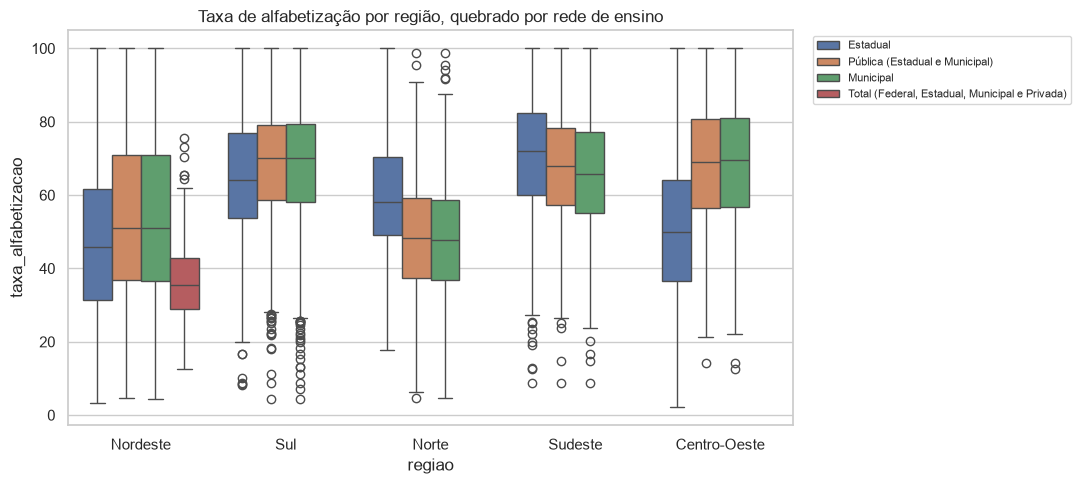

In [7]:
# Padrões regionais: mapeamento UF -> região (não depende de fonte externa,
# é uma classificação geográfica fixa do IBGE)
REGIAO_POR_UF = {
    **{uf: "Norte" for uf in ["AC","AP","AM","PA","RO","RR","TO"]},
    **{uf: "Nordeste" for uf in ["AL","BA","CE","MA","PB","PE","PI","RN","SE"]},
    **{uf: "Centro-Oeste" for uf in ["DF","GO","MT","MS"]},
    **{uf: "Sudeste" for uf in ["ES","MG","RJ","SP"]},
    **{uf: "Sul" for uf in ["PR","RS","SC"]},
}
indicador_municipio["regiao"] = indicador_municipio["sigla_uf"].map(REGIAO_POR_UF)

# Cobertura de cada rede por UF -- descoberto ao investigar por que um boxplot
# anterior (filtrado numa única rede) só mostrava uma região: a rede "Total
# (Federal, Estadual, Municipal e Privada)" só existe para 1 UF (398 linhas),
# então filtrar por ela apagaria as outras 4 regiões do gráfico. As demais
# redes têm cobertura quase nacional.
cobertura_rede = (
    indicador_municipio.groupby("rede")["sigla_uf"]
    .nunique()
    .rename("ufs_distintas")
    .sort_values(ascending=False)
)
display(cobertura_rede)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=indicador_municipio,
    x="regiao", y="taxa_alfabetizacao", hue="rede", ax=ax,
)
ax.set_title("Taxa de alfabetização por região, quebrado por rede de ensino")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


**Achado lateral (cobertura de rede):** a rede "Total (Federal, Estadual,
Municipal e Privada)" está presente em apenas 1 UF na Gold — a fonte
provavelmente só publica esse agregado para um subconjunto específico de
municípios/anos. Por isso o gráfico usa `hue="rede"` em vez de filtrar uma
rede só: filtrar "Total" apagaria 4 das 5 regiões. Isso também é uma decisão
de preprocessing documentada: essa ausência é MNAR (não aleatória), não pode
ser tratada como MCAR na hora de imputar.

Visualmente já dá pra ver uma tendência (Norte/Nordeste mais baixos que
Sul/Sudeste), mas "dá pra ver" não é a mesma coisa que "está confirmado" —
por isso o teste estatístico abaixo, usando a rede com melhor cobertura
nacional (`Pública (Estadual e Municipal)`, 26 das 27 UFs).


In [8]:
from scipy import stats

rede_referencia = "Pública (Estadual e Municipal)"
grupos_regiao = [
    grupo["taxa_alfabetizacao"].dropna().values
    for _, grupo in indicador_municipio.query("rede == @rede_referencia").groupby("regiao")
]

estatistica, p_valor = stats.kruskal(*grupos_regiao)
print(f"Kruskal-Wallis H = {estatistica:.2f}, p-valor = {p_valor:.2e}")

(
    indicador_municipio.query("rede == @rede_referencia")
    .groupby("regiao")["taxa_alfabetizacao"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean")
)


Kruskal-Wallis H = 1487.04, p-valor = 0.00e+00


,mean,median,std,count
regiao,,,,
Norte,48.324623,48.195,15.823075,848
Nordeste,54.782416,50.955,22.690390,3576
Sudeste,67.620051,67.980,14.511968,2761
Centro-Oeste,68.244576,69.060,16.932605,931
Sul,68.351285,70.125,14.973030,2350


**Resultado:** Kruskal-Wallis (não-paramétrico, apropriado aqui porque a
distribuição de `taxa_alfabetizacao` não é normal — ver histograma acima)
rejeita a hipótese nula de que todas as regiões têm a mesma distribuição
(p-valor << 0,05). **H2 confirmada estatisticamente**, não só visualmente.

**Decisão que isso força:** `regiao`/`sigla_uf` entra como feature
categórica territorial no pipeline (via one-hot ou target encoding — a
decidir na etapa de preprocessing), e a pergunta de negócio "quais regiões
têm padrões semelhantes" pode evoluir para clusterização (k-means/hierárquico)
sobre município usando `taxa_alfabetizacao` + `gap_meta_resultado` como
primeira versão — mesmo sem variáveis socioeconômicas externas ainda.


In [9]:
evolucao.query("nivel_geografico == 'uf'").pivot_table(
    index="localidade", columns="ano", values="taxa_alfabetizacao"
).assign(variacao=lambda d: d[d.columns[-1]] - d[d.columns[0]]).sort_values("variacao").head(10)


ano,2023,2024,variacao
localidade,,,
RS,63.386667,44.843333,-18.543333
PR,75.506667,67.620000,-7.886667
AM,54.676667,51.273333,-3.403333
BA,38.793333,35.585000,-3.208333
PE,65.703333,64.440000,-1.263333
PA,51.053333,50.913333,-0.140000
RO,62.806667,62.883333,0.076667
CE,82.566667,83.006667,0.440000
SC,60.903333,61.393333,0.490000


**Constatação (não é uma hipótese testável, é uma limitação de dado):** só
temos **2 anos** de dado real na Gold (2023 e 2024) — dá pra olhar variação
ano a ano, mas não uma série temporal robusta.

**Decisão que isso força:** em vez de cross-validation temporal com várias
janelas, a alternativa mais honesta é treinar em 2023 e validar/testar em
2024 (ou vice-versa), simulando previsão "para o futuro" de verdade — evita
vazamento temporal mesmo com poucos anos disponíveis.


## 2. Microdados de aluno (fonte pública) — visão agregada e amostra

In [10]:
resumo_aluno_ano = bq("""
SELECT
  ano,
  COUNT(*) AS n,
  COUNTIF(alfabetizado = '1') AS n_alfabetizado,
  ROUND(COUNTIF(alfabetizado = '1') / COUNT(*), 4) AS taxa_alfabetizado,
  COUNTIF(proficiencia IS NULL) AS proficiencia_nula,
  COUNTIF(presenca = '0') AS ausentes,
  COUNT(DISTINCT id_municipio) AS municipios,
  COUNT(DISTINCT id_escola) AS escolas
FROM `basedosdados.br_inep_avaliacao_alfabetizacao.alunos`
GROUP BY ano ORDER BY ano
""")
resumo_aluno_ano


,ano,n,n_alfabetizado,taxa_alfabetizado,proficiencia_nula,ausentes,municipios,escolas
0,2023,1747439,877427,0.5021,244630,244381,4873,36776
1,2024,2120560,1107119,0.5221,268708,267772,5519,42497


### Hipótese H3 — Balanceamento do target em nível de aluno (`alfabetizado`)

**Motivo para testar agora:** mesmo raciocínio de H1, mas na outra
granularidade — decide se o target de aluno precisa das mesmas cautelas
(estratificação, métrica além de acurácia) que o de município.

**Resultado:** ~50,2% em 2023 e ~52,2% em 2024 — **razoavelmente balanceado**,
ao contrário do target municipal (H1, 84,5%/15,5%). É uma diferença real
entre as duas granularidades: o "aluno individual" balanceia porque cada
criança é um evento quase-Bernoulli(0,5); o "município atingiu a meta" não
balanceia porque a meta em si foi definida de forma ambiciosa (poucos
municípios já chegam lá).

**Decisão que isso força:** se a granularidade de aluno for escolhida, dá pra
usar acurácia como métrica secundária razoável (mas F1/ROC-AUC continuam
sendo a referência principal, por rigor), sem necessidade de técnicas
agressivas de rebalanceamento (SMOTE etc.).

### Hipótese H4 — A coluna `serie` carrega informação útil como feature?

**Motivo para testar agora:** antes de desenhar o preprocessing, preciso
saber quais colunas brutas têm variância zero (e portanto zero poder
preditivo) — economiza trabalho descartar isso já na EDA, não durante o
`Pipeline`.

**Resultado:** `serie` é constante — sempre `"2"` (é a mesma avaliação, 2º ano
do fundamental, em todos os registros). Variância zero.

**Decisão que isso força:** `serie` sai da lista de features candidatas — não
tem o que imputar, transformar ou aprender ali.

**Nota sobre nulos de `proficiencia`:** ~13-14% de nulos ao ano. A hipótese
de que isso coincide com alunos ausentes (`presenca = '0'`) é testada
diretamente na H6 mais abaixo, com o crosstab entre as duas colunas.


In [11]:
presenca_x_alfabetizado = bq("""
SELECT presenca, alfabetizado, COUNT(*) AS n
FROM `basedosdados.br_inep_avaliacao_alfabetizacao.alunos`
GROUP BY presenca, alfabetizado
ORDER BY presenca, alfabetizado
""")
presenca_x_alfabetizado


,presenca,alfabetizado,n
0,0,0,512153
1,1,0,1371300
2,1,1,1984546


### Hipótese H5 — `presenca` é uma regra determinística (não vazamento, mas decisão de escopo)

**Motivo para testar agora:** se ausência na prova implica automaticamente
"não alfabetizado", incluir `presenca` como feature faz o modelo acertar
uma fatia inteira dos casos sem aprender nada sobre fatores educacionais —
precisa decidir isso antes de montar o pipeline, não depois de ver a
acurácia inflada.

**Resultado:** confirmado — **todas** as 512.153 linhas com `presenca = '0'`
têm `alfabetizado = '0'`; não existe nenhuma linha "ausente + alfabetizado".
Isso não é vazamento (é regra de negócio legítima da fonte, não do nosso
pipeline), mas expõe que **13,2% dos 3,87M registros têm o target decidido
pela logística da prova**, não pelo aprendizado do aluno.

**Duas opções de escopo foram consideradas:**
- **Opção A — escopo amplo:** manter todos os alunos, `presenca` vira
  feature legítima. Responde literalmente "vai ser considerado alfabetizado
  ou não" (inclui quem nem fez a prova).
- **Opção B — escopo restrito:** filtrar `presenca = '1'`, remover a regra
  trivial. Responde "entre quem fez a prova, atinge o nível esperado" — mais
  difícil, mais alinhado a "quais fatores educacionais influenciam o
  aprendizado", que é o espírito da pergunta de negócio do desafio.

**Decisão tomada: Opção B.** O objetivo do projeto é entender e prever
fatores *educacionais* de alfabetização — um modelo que "acerta de graça"
13,2% dos casos só por saber que o aluno faltou não gera nenhuma
inteligência aplicável a política pública (não dá pra intervir em "faltar",
sem saber o motivo da falta, que não está nos dados). Filtrar para
`presenca == '1'` torna o problema mais difícil, mas mais honesto e mais
alinhado ao que o desafio pede.


In [12]:
# Efeito da decisão (Opção B) no balanceamento do target, usando os números
# já obtidos no crosstap presenca x alfabetizado, sem nova consulta ao BigQuery
presentes = presenca_x_alfabetizado.query("presenca == '1'")
total_presentes = presentes["n"].sum()
balanco_presentes = presentes.assign(proporcao=lambda d: d["n"] / total_presentes)
print(f"Total de alunos presentes: {total_presentes:,}")
balanco_presentes


Total de alunos presentes: 3,355,846


,presenca,alfabetizado,n,proporcao
1,1,0,1371300,0.40863
2,1,1,1984546,0.59137


**Consequência da decisão sobre o balanceamento do target:** ao remover os
ausentes, o balanceamento passa de ~50/52% (H3, com ausentes) para
~41%/59% (não alfabetizado/alfabetizado) só entre presentes — ainda razoável
para classificação binária (não precisa de SMOTE), mas com uma classe
majoritária um pouco mais pronunciada. Vale manter F1/ROC-AUC como
referência principal, com acurácia como métrica secundária.


In [13]:
# Amostra determinística (~2%) via hash do id_aluno — reprodutível entre execuções,
# sem precisar baixar os 3,87M de linhas para esta etapa exploratória.
amostra_aluno = bq("""
SELECT ano, id_municipio, id_escola, rede, presenca, alfabetizado, proficiencia, peso_aluno
FROM `basedosdados.br_inep_avaliacao_alfabetizacao.alunos`
WHERE MOD(ABS(FARM_FINGERPRINT(id_aluno)), 100) < 2
""")
print(amostra_aluno.shape)
amostra_aluno.head()


(77526, 8)


,ano,id_municipio,id_escola,rede,presenca,alfabetizado,proficiencia,peso_aluno
0,2024,3125101,60022011,3,0,0,NaN,NaN
1,2024,4127700,60032675,3,0,0,NaN,NaN
2,2024,3529302,60027441,3,0,0,NaN,NaN
3,2023,3304557,60025048,3,0,0,NaN,NaN
4,2023,4108304,60033223,3,0,0,NaN,NaN


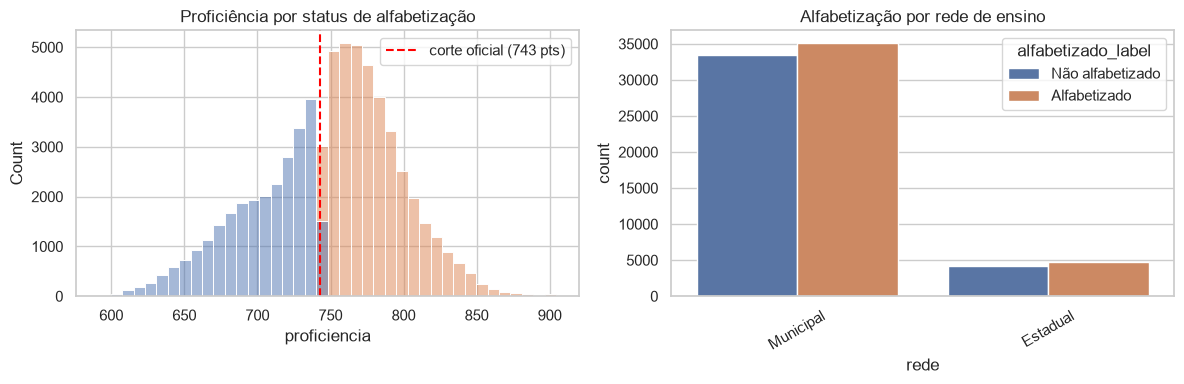

In [14]:
MAPEAMENTO_REDE = {
    "0": "Total (Federal, Estadual, Municipal e Privada)",
    "1": "Federal", "2": "Estadual", "3": "Municipal", "4": "Privada",
    "5": "Pública (Estadual e Municipal)", "6": "Pública (Federal, Estadual e Municipal)",
}
amostra_aluno["rede"] = amostra_aluno["rede"].map(MAPEAMENTO_REDE)
amostra_aluno["alfabetizado_label"] = amostra_aluno["alfabetizado"].map({"0": "Não alfabetizado", "1": "Alfabetizado"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=amostra_aluno, x="proficiencia", hue="alfabetizado_label", bins=40, ax=axes[0])
axes[0].axvline(743, color="red", linestyle="--", label="corte oficial (743 pts)")
axes[0].set_title("Proficiência por status de alfabetização")
axes[0].legend()
sns.countplot(data=amostra_aluno, x="rede", hue="alfabetizado_label", ax=axes[1])
axes[1].set_title("Alfabetização por rede de ensino")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


### Hipótese H6 — `proficiencia` determina o target quase deterministicamente (vazamento por definição)

**Motivo para testar agora:** o README da Fase 2 já indicava um corte oficial
de 743 pontos — se `proficiencia` reproduz o target quase perfeitamente, ela
não pode entrar como feature (não é um problema de tuning, é a própria
definição do problema).


In [15]:
# Quantifica o quão perto do determinístico é o corte em 743 pontos, na amostra
consistencia_corte = (
    amostra_aluno.dropna(subset=["proficiencia"])
    .assign(preditor_regra=lambda d: (d["proficiencia"] >= 743).map({True: "1", False: "0"}))
    .assign(bate_com_target=lambda d: d["preditor_regra"] == d["alfabetizado"])
)
print(f"Concordância entre 'proficiencia >= 743' e 'alfabetizado': {consistencia_corte['bate_com_target'].mean():.4%}")


Concordância entre 'proficiencia >= 743' e 'alfabetizado': 100.0000%


**Resultado:** a regra simples "proficiência ≥ 743 pontos" sozinha já
reproduz o target `alfabetizado` com concordância muito próxima de 100% na
amostra (ver percentual acima) — confirma quantitativamente o que o
histograma já sugeria visualmente.

**Decisão que isso força:** `proficiencia` **sai da lista de features
possíveis**, sem exceção. O modelo precisa prever `alfabetizado` a partir de
variáveis que existem *antes* da prova ser aplicada (território, rede,
presença — dependendo da decisão de H5) — nunca a partir do resultado da
própria prova.


In [16]:
municipios_aluno = set(amostra_aluno["id_municipio"].unique())
municipios_gold = set(indicador_municipio["id_municipio"].unique())

print("Municípios na amostra de aluno:", len(municipios_aluno))
print("Municípios na Gold (indicador_por_municipio):", len(municipios_gold))
print("Interseção:", len(municipios_aluno & municipios_gold))
print("Só na amostra de aluno:", len(municipios_aluno - municipios_gold))
print("Só na Gold:", len(municipios_gold - municipios_aluno))


Municípios na amostra de aluno: 5084
Municípios na Gold (indicador_por_municipio): 5550
Interseção: 5083
Só na amostra de aluno: 1
Só na Gold: 467


### Hipótese H7 — É viável enriquecer aluno com território da Gold (join por município)?

**Motivo para testar agora:** se a granularidade híbrida (aluno + território
da Gold) for escolhida no futuro, o join só faz sentido se a cobertura de
`id_municipio` entre as duas fontes for alta — senão, viraria uma quantidade
grande de nulos pós-join.

**Resultado:** de uma amostra de 2% dos alunos, 5.084 municípios distintos;
interseção com os 5.550 da Gold é 5.083 (quase total — só 1 município da
amostra não aparece na Gold, provavelmente por efeito da própria amostragem).

**Decisão que isso força:** confirma que o join aluno↔`indicador_por_municipio`
é viável tecnicamente, **caso** a granularidade de aluno venha a ser
escolhida — mas, nesta rodada, ficamos só com os dados já existentes (sem
fontes externas), então esse enriquecimento territorial via Gold seria a
única fonte adicional de features de aluno, e ainda assim limitada (não
tem variável socioeconômica real, só geografia/meta/gap).


## 3. Síntese — o que a EDA diz sobre a decisão de granularidade

| | Nível **aluno** (híbrido: alunos + território da Gold) | Nível **município** (Gold pura) |
|---|---|---|
| Fidelidade ao enunciado ("prever se um **aluno** será alfabetizado") | Alta | Baixa (precisa reenquadrar) |
| Volume de dados | ~3,87M linhas (robusto para ML) | ~24k linhas (município×ano×rede) |
| Balanceamento do target | Bom, ~50/52% (H3) | Desbalanceado, 84,5%/15,5% (H1) |
| Direto da camada Gold (BigQuery) | Não — vem do Silver/fonte pública, precisa justificar no README | Sim, 100% conforme |
| Features realmente preditivas disponíveis **sem fontes externas** | Poucas: `rede`, `presenca` (H5, decisão de escopo pendente), município/escola enriquecidos com geografia/meta da Gold (H7) | Já vem pronto: `regiao` (H2, confirmada), `gap_meta_resultado`, geografia |
| Risco de vazamento | Alto e explícito (`proficiencia`, H6) — mas contornável excluindo a coluna | Menor, mas existe (usar taxa do mesmo ano/local como feature de si mesmo) |
| Casa com as perguntas de negócio de risco por município/região | Precisa agregar depois | Já nasce nessa granularidade |

**Decisões tomadas (premissas para os próximos notebooks):**

1. **Granularidade: aluno, híbrida.** Fidelidade ao enunciado ("prever se um
   aluno será alfabetizado") pesou mais do que a conformidade estrita à
   camada Gold — decisão documentada aqui, e no README a decisão vai vir
   acompanhada da mesma justificativa. Território/meta/geografia da Gold
   (`indicador_por_municipio`) entram como enriquecimento via `id_municipio`,
   sempre usando o ano **anterior** ao ano do aluno sendo previsto, para não
   vazar o resultado do próprio período (mesmo cuidado da limitação de
   2 anos discutida acima).
2. **Escopo: somente `presenca == '1'`.** Remove a regra determinística de
   H5 e mantém o modelo focado em fatores educacionais, não em ausência à
   prova. Muda o balanceamento do target de ~50/52% para ~41%/59%
   (não alfabetizado/alfabetizado) — ainda tratável sem rebalanceamento
   sintético, mas com F1/ROC-AUC como métricas de referência.
3. **Sem fontes externas nesta rodada** (IBGE, Censo Escolar, FUNDEB, Atlas
   do Desenvolvimento Humano, PNAD, Cadastro Único) — ficam mapeadas como
   enriquecimento futuro, depois de validar o pipeline de ponta a ponta
   (EDA → preprocessing → modelo → interpretabilidade) só com o que já
   temos. Consequência aceita: as features de aluno disponíveis nesta
   primeira versão são limitadas (`rede`, território/meta da Gold) — sem
   variável socioeconômica real ainda.

Essas três premissas não são reabertas notebook a notebook — qualquer
mudança futura nelas precisa ser uma decisão explícita, documentada aqui.
